- Tóm tắt quy trình xử lý dữ liệu: Mô tả cách dataset Caltech256 được tải, chia thành các tập train/val/test và các kỹ thuật tiền xử lý, tăng cường dữ liệu được áp dụng (ví dụ: Resize, CenterCrop, RandomHorizontalFlip, ColorJitter, Normalize).
- Liệt kê mô hình học máy truyền thống: Xác định các mô hình học máy truyền thống (Logistic Regression, Linear SVM, Random Forest) đã được sử dụng. Nêu rõ cách các đặc trưng được trích xuất (ví dụ: từ ResNet50), các bước chuẩn hóa (StandardScaler) và giảm chiều (PCA) đã được áp dụng, cũng như phương pháp tối ưu hóa (GridSearchCV).
- Liệt kê mô hình học sâu: Xác định các kiến trúc mạng học sâu (ResNet18, EfficientNet-B0, MobileNetV3-Large, và ViT-B/16 đã được khởi tạo) đã được huấn luyện. Mô tả các kỹ thuật fine-tuning, bộ tối ưu hóa (Adam), và lịch trình learning rate (StepLR) đã được sử dụng cho các mô hình này. Lưu ý cả việc sử dụng Mixed Precision Training (AMP) cho ViT-B/16.
-edited: vi le

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/caltech256")

print("Path to dataset files:", path)

D:\Hung-Dung\HCMUT\252\Machine Learning\Caltech-ML-Assignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\nguye\.cache\kagglehub\datasets\jessicali9530\caltech256\versions\2


In [2]:
from pathlib import Path
import os
import random
import shutil
from tqdm import tqdm

SOURCE_DIR = path    # Raw dataset
TARGET_DIR = "split"

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
SEED = 42
random.seed(42)
def mkdir(path):
  os.makedirs(path, exist_ok=True)

def split_class(class_dir, class_name):
  images=[f for f in class_dir.glob("*") if f.is_file()]
  random.shuffle(images)
  n = len(images)

  n_trainn = int(n*TRAIN_RATIO)
  n_val = int(n*VAL_RATIO)

  train_imgs = images[:n_trainn]
  val_imgs = images[n_trainn:n_trainn+n_val]
  test_imgs  = images[n_trainn+n_val:]

  return train_imgs, val_imgs, test_imgs

def copy_files(files, split, class_name):
  dst_dir = Path(TARGET_DIR) / split / class_name
  mkdir(dst_dir)
  for file in files:
    shutil.copy2(file, dst_dir / file.name)

source = Path(SOURCE_DIR) / "256_ObjectCategories"

assert source.exists(), "Source folder not found!"

classes = [d for d in source.iterdir() if d.is_dir()]

print(f"Found {len(classes)} clases")
for split in ["train", "val", "test"]:
  mkdir(Path(TARGET_DIR) / split)
for class_dir in tqdm(classes):
  class_name = class_dir.name
  train_imgs, val_imgs, test_imgs = split_class(class_dir, class_name)
  copy_files(train_imgs, "train", class_name)
  copy_files(val_imgs, "val", class_name)
  copy_files(test_imgs, "test", class_name)
print("\nDone!")
print("Saved to:", TARGET_DIR)

Found 258 clases


100%|██████████████████████████████████████████████████████████████████████████| 258/258 [00:31<00:00,  8.20it/s]


Done!
Saved to: split


## EDA

### View one image

split\train\001.ak47\001_0046.jpg


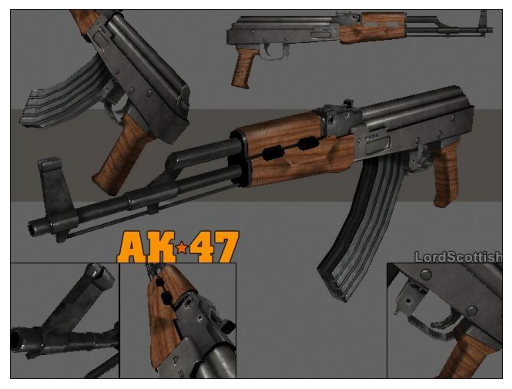

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import random
from pathlib import Path

folder = Path("split/train/001.ak47")

jpg_files = list(folder.glob("*.jpg"))

img_path = random.choice(jpg_files)
img = Image.open(img_path)

print(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

### Collect sizes and channels

In [4]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import cv2

brightness = []
sizes = []
channels = []

root = Path("split/train")

total_files = 0
processed = 0
skipped = 0

REPORT_EVERY = 20   # update every N images

for cls_dir in root.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        total_files += 1

        try:
            img = Image.open(img_path)
            sizes.append(img.size)

            channels.append(3 if img.mode == "RGB" else 1)

            img_cv = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

            if img_cv is None:
                skipped += 1
                continue

            brightness.append(img_cv.mean())
            processed += 1

            # Overwrite status line
            if processed % REPORT_EVERY == 0:
                print(
                    f"\rProcessed: {processed} | "
                    f"Scanned: {total_files} | "
                    f"Skipped: {skipped}",
                    end="",
                    flush=True
                )

        except (UnidentifiedImageError, OSError):
            skipped += 1
            continue


# Final newline + summary
print()  # move to next line
print("===== DONE =====")
print("Total files scanned:", total_files)
print("Successfully processed:", processed)
print("Skipped files:", skipped)

Processed: 21300 | Scanned: 21301 | Skipped: 1
===== DONE =====
Total files scanned: 21308
Successfully processed: 21307
Skipped files: 1


###Plot Size Distribution

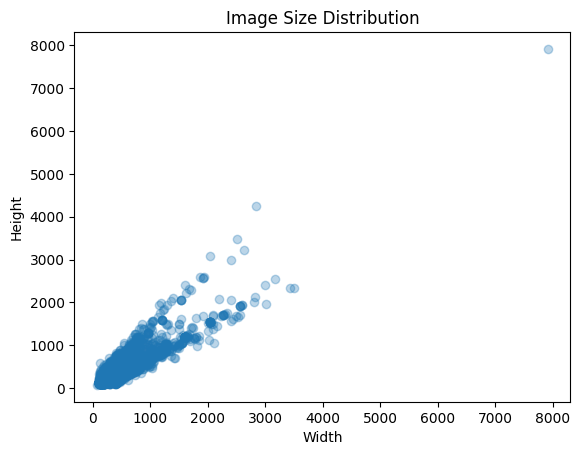

Width mean: 371.30741071009527
Height mean: 325.8275684047496
Min size: 75 75
Max size: 7913 7913


In [5]:
import matplotlib.pyplot as plt
import numpy as np

widths = np.array([s[0] for s in sizes])
heights = np.array([s[1] for s in sizes])

plt.scatter(widths, heights, alpha= 0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

print("Width mean:", widths.mean())
print("Height mean:", heights.mean())
print("Min size:", widths.min(), heights.min())
print("Max size:", widths.max(), heights.max())

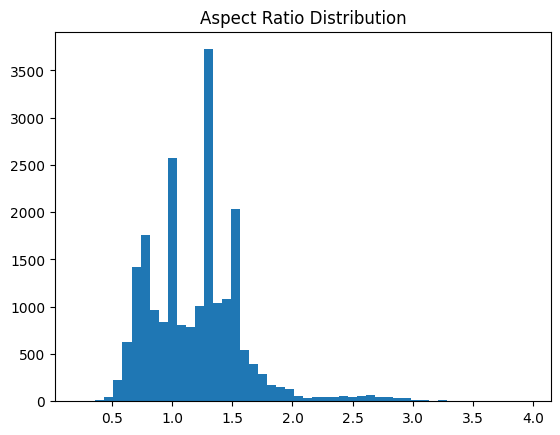

In [6]:
ratios = widths / heights

plt.hist(ratios, bins=50)
plt.title("Aspect Ratio Distribution")
plt.show()

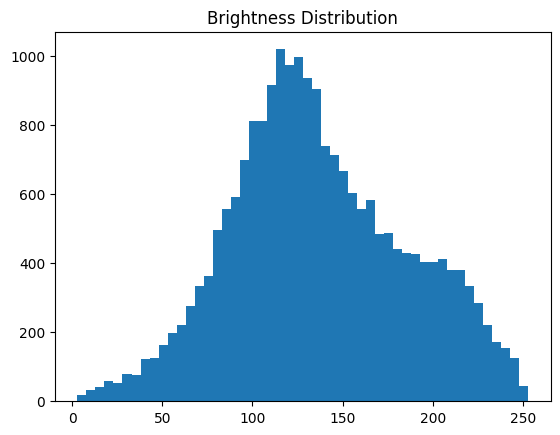

In [7]:
plt.hist(brightness, bins=50)
plt.title("Brightness Distribution")
plt.show()

The image size distribution shows that most samples fall within the range of 200–1500 pixels in both width and height (mostly sqaure). However, several outliers with very large resolutions (up to 8000×8000) were observed.

The majority of images have aspect ratios between 0.8 and 1.6, indicating near-square or mildly landscape-oriented compositions. A small number of extreme outliers (>2.5) were observed, suggesting that resizing to a fixed square input may introduce geometric distortion. To mitigate this, we employ resizing with center cropping.

The brightness distribution follows an approximately normal pattern centered around 130 (on a 0–255 scale), suggesting balanced illumination across the dataset. A small fraction of low-light and high-exposure images were detected, which motivates the use of normalization.



### Plot class distribtuion

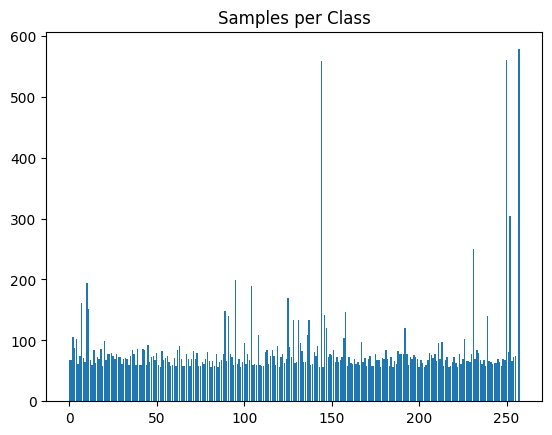

In [8]:
from collections import Counter

class_counts = {}

for cls in list(root.iterdir()):
    if not cls.is_dir():
        continue
    class_counts[cls] = len(list(cls.iterdir()))
plt.bar(range(len(class_counts)), list(class_counts.values()), align='center')
plt.title("Samples per Class")
plt.show()

The class distribution shows moderate imbalance, with most classes containing 50–80 samples, while a few classes have significantly more samples (up to ~580). This imbalance may bias the model toward majority classes.

To mitigate class imbalance, three common strategies were considered: weighted loss, data augmentation for minority classes, and oversampling.

## Preprocessing

Based on the EDA results, we design a preprocessing pipeline to standardize image inputs while preserving visual structure. Since most images exhibit near-square aspect ratios with some extreme outliers, we apply resizing to 256 pixels followed by center cropping to 224×224.

All images are converted to RGB format and normalized using ImageNet statistics to match the pretrained backbone models.

For the training set, we employ data augmentation including random horizontal flipping and mild color jittering to improve model generalization. Validation and test sets are processed without augmentation to ensure fair evaluation.

In [9]:
from torchvision import transforms
train_transform = transforms.Compose([
    # resize while aspect
    transforms.Resize(256),
    # center crop to 224
    transforms.CenterCrop(224),
    # random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),
    # color jitter
        # Slight color variation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

### Load dataset

In [13]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
train_dataset = ImageFolder(root="./split/train", transform=train_transform)

val_dataset = ImageFolder(root="split/val", transform=test_transform)
test_dataset = ImageFolder(root="split/test", transform=test_transform)


FileNotFoundError: Found no valid file for the classes 256_ObjectCategories. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

### Load data loader

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Visual sanity check

In [ ]:
import matplotlib.pyplot as plt
import torchvision

batch = next(iter(train_loader))
imgs, labels = batch

grid = torchvision.utils.make_grid(imgs[:16], nrow=4)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title("Preprocessed Training Images")
plt.show()

## Features extraction

In [ ]:
import torch
from torchvision import models, transforms
import torch.nn as nn

MODEL_NAME = "resnet50"
SAVE_PATH = "features"
DATA_DIR = "split/train"     # or train / val
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def load_model(name):

    if name == "resnet50":
        # Use the latest weights for better feature representation
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Identity()
        feat_dim = 2048


    elif name == "efficientnet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier = nn.Identity()
        feat_dim = 1280


    elif name == "vit":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        model.heads = nn.Identity()
        feat_dim = 768


    else:
        raise ValueError("Unknown model")

    return model, feat_dim

In [ ]:
model, FEATURE_DIM = load_model(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print("Using:", MODEL_NAME)
print("Feature dim:", FEATURE_DIM)

In [ ]:
import h5py
import numpy as np
from tqdm import tqdm
import torch

def extract_and_save_features(loader, split_name):
    print(f"Extracting features for {split_name} set...")
    features = []
    labels = []
    with torch.no_grad():
        # Add autocast to speed up feature extraction on GPU
        with torch.cuda.amp.autocast():
            for imgs, labs in tqdm(loader, desc=f"{split_name}"):
                imgs = imgs.to(DEVICE)
                feats = model(imgs)      # [B, D]
                features.append(feats.cpu().numpy())
                labels.append(labs.numpy())

    features = np.vstack(features)
    labels = np.hstack(labels)

    # Save in industry-standard HDF5 (.h5) format with gzip compression
    with h5py.File(f"{SAVE_PATH}/{MODEL_NAME}_{split_name}.h5", 'w') as hf:
        hf.create_dataset('X', data=features, compression='gzip')
        hf.create_dataset('y', data=labels, compression='gzip')
    print(f"{split_name} features shape:", features.shape)

## Static Deep Feature Extraction (Hybrid Pipeline)

In [ ]:
import os
import numpy as np
from google.colab import drive


# 2. Cấu hình thư mục lưu trữ trên Drive
PROJECT_DIR = '/content/drive/MyDrive/Caltech256_Project'
SAVE_PATH = f"{PROJECT_DIR}/features"
os.makedirs(SAVE_PATH, exist_ok=True) # Tự động tạo thư mục nếu chưa có
MODEL_NAME = "resnet50"

print(f"📂 Đã thiết lập thư mục lưu trữ tại: {SAVE_PATH}")

# 3. BẮT ĐẦU TRÍCH XUẤT VÀ LƯU RA FILE .H5
print("⏳ Đang tiến hành trích xuất đặc trưng (Sẽ tốn một chút thời gian)...")
extract_and_save_features(train_loader, "train")
extract_and_save_features(val_loader, "val")
extract_and_save_features(test_loader, "test")

# 4. CHỐT SỔ: Lưu danh sách tên 256 classes ra file .npy
class_names = train_dataset.classes
np.save(f"{SAVE_PATH}/{MODEL_NAME}_classes.npy", class_names)

print(f"\n✅ HOÀN TẤT! Đã lưu toàn bộ features và file classes (.npy) vào Google Drive.")

### Static Extraction (2048-D

In [ ]:
import h5py
import numpy as np
import os
import joblib
import time
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# --- CẤU HÌNH ĐƯỜNG DẪN (Phải khớp với Cell 1) ---
PROJECT_DIR = '/content/drive/MyDrive/Caltech256_Project'
SAVE_PATH = f"{PROJECT_DIR}/features"
MODEL_NAME = "resnet50"

# 1. Hàm load dữ liệu từ file HDF5 trên Drive
def load_h5_data(split_name):
    filepath = f"{SAVE_PATH}/{MODEL_NAME}_{split_name}.h5"
    with h5py.File(filepath, 'r') as hf:
        X = hf['X'][:]
        y = hf['y'][:]
    print(f"📥 Loaded {split_name} set: X shape {X.shape}, y shape {y.shape}")
    return X, y

print("Loading extracted features from Google Drive...")
X_train, y_train = load_h5_data("train")
X_val, y_val = load_h5_data("val")
X_test, y_test = load_h5_data("test")

# 2. Chuẩn hóa dữ liệu (Scaling)
print("\nScaling features...")
scaler = StandardScaler()
# Gộp train và val lại để GridSearchCV có nhiều dữ liệu hơn test chéo
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

# 3. Định nghĩa mô hình và không gian tham số (Parameter Grid)
print("\n🚀 Bắt đầu GridSearchCV cho Logistic Regression...")
start_time = time.time()

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0]
}

log_reg = LogisticRegression(max_iter=1000, random_state=42)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

# 4. Chạy tìm kiếm tham số
grid_search.fit(X_train_val_scaled, y_train_val)
train_time = time.time() - start_time

print(f"\n✅ Tìm kiếm hoàn tất trong: {train_time:.2f} giây")
print(f"🌟 Tham số TỐT NHẤT: {grid_search.best_params_}")
print(f"📈 Độ chính xác Cross-Validation: {grid_search.best_score_:.4f}")

# 5. Đánh giá mô hình tốt nhất trên tập Test
best_model = grid_search.best_estimator_

print("\n🏆 ĐÁNH GIÁ TRÊN TẬP TEST")
test_preds = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)
print(f"🔥 Final Test Accuracy: {test_acc:.4f}\n")

# 6. LƯU MÔ HÌNH LÊN GOOGLE DRIVE
model_path = f"{PROJECT_DIR}/best_log_reg_model.pkl"
scaler_path = f"{PROJECT_DIR}/scaler.pkl"

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path) # Lưu luôn cả scaler để sau này dùng cho ảnh mới

print(f"💾 Đã lưu mô hình an toàn tại: {model_path}")
print(f"💾 Đã lưu bộ chuẩn hóa (scaler) tại: {scaler_path}")

### Static + PCA (256-D)

In [ ]:
import h5py
import numpy as np
import time
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- CẤU HÌNH ĐƯỜNG DẪN ---
PROJECT_DIR = '/content/drive/MyDrive/Caltech256_Project'
SAVE_PATH = f"{PROJECT_DIR}/features"
MODEL_NAME = "resnet50"

# 1. Hàm load dữ liệu từ Drive
def load_h5_data(split_name):
    filepath = f"{SAVE_PATH}/{MODEL_NAME}_{split_name}.h5"
    with h5py.File(filepath, 'r') as hf:
        X = hf['X'][:]
        y = hf['y'][:]
    return X, y

print("📥 Đang nạp dữ liệu từ Google Drive...")
X_train, y_train = load_h5_data("train")
X_val, y_val = load_h5_data("val")
X_test, y_test = load_h5_data("test")

# Gộp Train và Val
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.hstack((y_train, y_val))

# 2. Chuẩn hóa và Ép nén (PCA)
print("\n⚖️ Đang chuẩn hóa và nén PCA (2048 -> 256 chiều)...")
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=256, random_state=42)
X_train_val_pca = pca.fit_transform(X_train_val_scaled)
X_test_pca = pca.transform(X_test_scaled)
joblib.dump(pca, f"{PROJECT_DIR}/pca_model.pkl") # Lưu đối tượng PCA
print("✅ Nén dữ liệu thành công! Sẵn sàng đua tốc độ.")

# 3. Khởi tạo các mô hình đối thủ
models = {
    # Dùng dual=False để tối ưu tốc độ cho dữ liệu lớn
    "Linear SVM (PCA)": LinearSVC(C=0.1, max_iter=1000, dual=False, random_state=42),

    # Rừng ngẫu nhiên 100 cây
    "Random Forest (PCA)": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

# 4. Bắt đầu huấn luyện và so sánh
print("\n🏎️ BẮT ĐẦU HUẤN LUYỆN VÀ SO SÁNH...")
results = {}

for name, model in models.items():
    print(f"\n⏳ Đang train {name}...")
    start_time = time.time()

    # Train
    model.fit(X_train_val_pca, y_train_val)
    train_time = time.time() - start_time

    # Dự đoán
    test_preds = model.predict(X_test_pca)
    test_acc = accuracy_score(y_test, test_preds)

    print(f"✅ Xong trong: {train_time:.2f} giây")
    print(f"🔥 Độ chính xác (Accuracy): {test_acc:.4f}")

    # Lưu mô hình
    model_file_path = f"{PROJECT_DIR}/{name.replace(' ', '_').replace('_(PCA)', '').lower()}_pca_model.pkl"
    joblib.dump(model, model_file_path)

    results[name] = test_acc

# 5. Bảng tổng kết
print("\n" + "="*40)
print("🏆 BẢNG XẾP HẠNG MÔ HÌNH (SAU KHI DÙNG PCA)")
print("="*40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f" ➖ {name}: {acc*100:.2f}%")
print("="*40)

### Report results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cấu hình dữ liệu từ kết quả huấn luyện
models = ['Logistic Regression\n(2048D - Không PCA)',
          'Linear SVM\n(256D - Có PCA)',
          'Random Forest\n(256D - Có PCA)']

accuracies = [88.23, 84.93, 78.82]
times = [677.95, 253.40, 262.25] # Lưu ý: Thời gian LogReg là của cả quá trình GridSearchCV (12 fits)

# 2. Cấu hình giao diện biểu đồ (Style chuyên nghiệp cho báo cáo)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Tạo một figure gồm 2 biểu đồ nằm cạnh nhau (1x2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# BIỂU ĐỒ 1: SO SÁNH ĐỘ CHÍNH XÁC (ACCURACY)
# ==========================================
# Dùng màu xanh lá cho model tốt nhất, màu xanh dương cho các model còn lại
colors_acc = ['#2ecc71' if acc == max(accuracies) else '#3498db' for acc in accuracies]
bars_acc = ax1.bar(models, accuracies, color=colors_acc, edgecolor='black', linewidth=1.2)

ax1.set_title('So sánh Độ chính xác (Test Accuracy) trên tập Caltech-256', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100) # Cố định trục Y từ 0 đến 100%

# Thêm con số % trực tiếp lên đỉnh mỗi cột
for bar in bars_acc:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1.5,
             f'{height:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# ==========================================
# BIỂU ĐỒ 2: SO SÁNH THỜI GIAN HUẤN LUYỆN
# ==========================================
colors_time = ['#e74c3c', '#f1c40f', '#e67e22']
bars_time = ax2.bar(models, times, color=colors_time, edgecolor='black', linewidth=1.2)

ax2.set_title('So sánh Thời gian xử lý (Giây)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Thời gian (s)', fontsize=12, fontweight='bold')

# Thêm con số giây trực tiếp lên đỉnh mỗi cột
for bar in bars_time:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{height:.1f}s',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Thêm dòng chú thích nhỏ dưới biểu đồ 2 để đảm bảo tính minh bạch
ax2.text(-0.5, -150, "* Lưu ý: Thời gian của Logistic Regression bao gồm cả quá trình tìm kiếm siêu tham số (GridSearchCV 12 vòng).",
         fontsize=10, style='italic', color='gray')

# 3. Hiển thị và lưu biểu đồ
plt.tight_layout()

# Bạn có thể lưu biểu đồ thành file ảnh độ phân giải cao để chèn vào báo cáo
# plt.savefig('/content/drive/MyDrive/Caltech256_Project/model_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

### 2. Get class_names from train_dataset (Fix undefined variable error)

In [ ]:
class_names = train_dataset.classes
np.save(f"{SAVE_PATH}/{MODEL_NAME}_classes.npy", class_names)

print("Saved to:", SAVE_PATH)

## Deep-learning

In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# --- CONFIGURATION ---
# Save models to Drive so you don't lose them when Colab disconnects
PROJECT_DIR = '/content/drive/MyDrive/Caltech256_Project'
MODEL_SAVE_DIR = f"{PROJECT_DIR}/dl_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# LOAD DATA FROM LOCAL COLAB STORAGE (Lightning Fast!)
DATA_DIR = "/content/split"

BATCH_SIZE = 32
NUM_CLASSES = 257
NUM_EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔹 Using device: {DEVICE}")

# --- DATA PREPARATION ---
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=f"{DATA_DIR}/train", transform=transform_train)
val_dataset = ImageFolder(root=f"{DATA_DIR}/val", transform=transform_test)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

# --- UNIVERSAL TRAINING FUNCTION ---
def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} | ', end='')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | ', end='')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'\n🏆 {model_name} Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'🔥 Best Val Accuracy: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    save_path = f"{MODEL_SAVE_DIR}/{model_name}_best.pth"
    torch.save(model.state_dict(), save_path)
    print(f"💾 Saved best model to: {save_path}\n")
    return model

RESNET 18


In [ ]:
print("🚀 Initializing ResNet18...")
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final fully connected layer
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, NUM_CLASSES)
model_ft = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4) # Lower LR for fine-tuning
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_resnet18 = train_model(model_ft, "ResNet18", criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

EfficientNet-B0

In [ ]:
print("🚀 Initializing EfficientNet-B0...")
model_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# EfficientNet uses a 'classifier' block ending in a dropout and linear layer
num_ftrs = model_ft.classifier[1].in_features
model_ft.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
model_ft = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_effnet = train_model(model_ft, "EfficientNet_B0", criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

In [ ]:
print("🚀 Initializing MobileNetV3-Large...")
model_ft = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

# MobileNetV3 uses a classifier sequential block, the last layer is index 3
num_ftrs = model_ft.classifier[3].in_features
model_ft.classifier[3] = nn.Linear(num_ftrs, NUM_CLASSES)
model_ft = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_mobilenet = train_model(model_ft, "MobileNetV3_Large", criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
# --- CONFIGURATION ---
# Save models to Drive so you don't lose them when Colab disconnects
PROJECT_DIR = '/content/drive/MyDrive/Caltech256_Project'
MODEL_SAVE_DIR = f"{PROJECT_DIR}/dl_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# LOAD DATA FROM LOCAL COLAB STORAGE (Lightning Fast!)
DATA_DIR = "/content/split"

BATCH_SIZE = 32
NUM_CLASSES = 257
NUM_EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔹 Using device: {DEVICE}")

# --- DATA PREPARATION ---
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=f"{DATA_DIR}/train", transform=transform_train)
val_dataset = ImageFolder(root=f"{DATA_DIR}/val", transform=transform_test)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

# --- UNIVERSAL TRAINING FUNCTION ---
def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=20):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # NEW: Thêm Scaler cho Mixed Precision
    scaler = GradScaler()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} | ', end='')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                # NEW: Chạy lan truyền xuôi (Forward pass) trong môi trường Float16
                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(): # Bật AMP ở đây
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        # NEW: Lan truyền ngược (Backward) bằng Scaler
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | ', end='')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'\n🏆 {model_name} (AMP Tăng Tốc) Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'🔥 Best Val Accuracy: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    save_path = f"{MODEL_SAVE_DIR}/{model_name}_best.pth"
    torch.save(model.state_dict(), save_path)
    print(f"💾 Saved best model to: {save_path}\n")
    return model

In [ ]:
print("🚀 Initializing ViT-B/16...")
model_ft = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# ViT uses a 'heads' block, specifically 'heads.head' for the final classification
num_ftrs = model_ft.heads.head.in_features
model_ft.heads.head = nn.Linear(num_ftrs, NUM_CLASSES)
model_ft = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_vit = train_model(model_ft, "ViT_B_16", criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)